<a href="https://colab.research.google.com/gist/Brijkishore-lab/a0cd6faff0e4840192befee12496890d/india_spacelab_projects_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 India Space Lab — Comprehensive Project Notebook
### Project Period: 01 May – 15 June 2026
---
**This notebook covers all four India Space Lab projects:**
1. 🛰️ **Project 1** – CanSat GCS Telemetry Simulator
2. 🌡️ **Project 2** – Heat Wave Data Analysis & Visualization
3. 🚀 **Project 3** – Rocketry FEM/CFD Theory & Analysis
4. 🤖 **Project 4** – Drone PID Control & Autonomous Boat Guidance

---
**Student Name:** Brijkishore Anilkumar Agarwal

**Institute Name:** MIT ADT UNIVERSITY PUNE INDIA

**Enrollment No.:** ISL-272719

**Email ID.:** brijkishore.agarwal@mituniversity.edu.in


## 📦 Installation & Imports
Run this cell first to install all required libraries.

In [1]:
# Install required packages
!pip install numpy matplotlib pandas ipywidgets scipy -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
import pandas as pd
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from scipy.integrate import odeint
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor'] = '#161B22'
plt.rcParams['axes.edgecolor'] = '#30363D'
plt.rcParams['text.color'] = '#E6EDF3'
plt.rcParams['axes.labelcolor'] = '#E6EDF3'
plt.rcParams['xtick.color'] = '#E6EDF3'
plt.rcParams['ytick.color'] = '#E6EDF3'
plt.rcParams['grid.color'] = '#21262D'
plt.rcParams['grid.alpha'] = 0.5

display(HTML("""<div style='background:#0D1117;padding:16px;border-radius:8px;
border-left:4px solid #2563EB;'>
<span style='color:#58A6FF;font-size:16px;font-weight:bold;'>✅ All libraries loaded successfully!</span><br>
<span style='color:#8B949E;'>NumPy, Matplotlib, Pandas, ipywidgets, SciPy ready.</span>
</div>"""))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.3 MB/s eta 0:00:00


---
## 🛰️ PROJECT 1: CanSat Ground Control Software — Telemetry Simulator

**Objective:** Simulate CanSat telemetry data and visualize it as a real Ground Control Software (GCS) would.

This section simulates:
- Real-time telemetry data generation
- Altitude, Pressure, Temperature, Descent Rate, Battery graphs
- 4-digit Error Code system
- GPS tracking simulation
- Mission state machine


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CANSAT TELEMETRY DATA GENERATOR
# Simulates a CanSat mission: launch → ascent → peak → descent → landing
# ─────────────────────────────────────────────────────────────────────────────

class CanSatTelemetry:
    """Simulates CanSat telemetry packets for a complete mission."""

    def __init__(self, total_time=120, dt=1.0):
        self.dt = dt
        self.t = np.arange(0, total_time, dt)
        self.n = len(self.t)
        self._generate()

    def _generate(self):
        t = self.t
        n = self.n

        # Mission phases (seconds)
        t_launch = 0
        t_peak   = 40
        t_deploy = 45   # Parachute deploy
        t_land   = 110

        # ALTITUDE (m): boost → coast → descent under parachute
        alt = np.zeros(n)
        for i, ti in enumerate(t):
            if ti < t_peak:
                alt[i] = 500 * (ti/t_peak)**2
            elif ti < t_land:
                alt[i] = 500 * np.exp(-0.035*(ti-t_peak))
        alt = np.clip(alt, 0, None)
        self.altitude = alt + np.random.normal(0, 2, n)

        # PRESSURE (hPa): inversely related to altitude
        self.pressure = 1013.25 * np.exp(-self.altitude / 8500)
        self.pressure += np.random.normal(0, 0.3, n)

        # TEMPERATURE (°C): decreases with altitude, increases near ground
        self.temperature = 25 - 0.0065 * self.altitude
        self.temperature += np.random.normal(0, 0.5, n)

        # DESCENT RATE (m/s): positive = descending
        self.descent_rate = np.zeros(n)
        for i in range(1, n):
            dr = (self.altitude[i-1] - self.altitude[i]) / self.dt
            self.descent_rate[i] = max(0, dr)
        # Add free-fall phase before chute
        for i, ti in enumerate(t):
            if t_peak <= ti < t_deploy:
                self.descent_rate[i] = min(30, 9.8*(ti-t_peak))
        self.descent_rate += np.abs(np.random.normal(0, 0.2, n))

        # BATTERY VOLTAGE (V): slowly depletes
        self.battery = 8.4 - 0.02*(t/t_land) + np.random.normal(0, 0.05, n)
        self.battery = np.clip(self.battery, 6.0, 8.4)

        # GPS COORDINATES (simulate trajectory)
        lat0, lon0 = 28.6139, 77.2090   # New Delhi
        self.lat = lat0 + 0.001 * np.cumsum(np.random.normal(0, 0.01, n)) / n
        self.lon = lon0 + 0.001 * np.cumsum(np.random.normal(0, 0.01, n)) / n

        # PACKET COUNT
        self.packet = np.arange(1, n+1)

        # GPS LOCK (drops when altitude > 400m randomly)
        self.gps_lock = np.ones(n, dtype=bool)
        for i in range(n):
            if self.altitude[i] > 400 and np.random.rand() < 0.05:
                self.gps_lock[i] = False

        # PAYLOAD SEPARATION (at t=46s)
        self.payload_sep = np.array([ti >= t_deploy+1 for ti in t])

        # PARACHUTE (deployed at t=45s)
        self.chute_active = np.array([ti >= t_deploy for ti in t])

    def error_code(self, i):
        d1 = 0 if 8 <= self.descent_rate[i] <= 10 or self.altitude[i] < 5 else 1
        d2 = 0 if self.gps_lock[i] else 1
        d3 = 0 if self.payload_sep[i] else 1
        d4 = 1 if self.chute_active[i] else 0
        return f"{d1}{d2}{d3}{d4}"

# Generate telemetry
telem = CanSatTelemetry(total_time=120, dt=1.0)
print("✅ CanSat telemetry generated:")
print(f"   Mission duration : {telem.t[-1]:.0f} seconds")
print(f"   Peak altitude    : {telem.altitude.max():.1f} m")
print(f"   Total packets    : {telem.n}")
print(f"   Final error code : {telem.error_code(-1)}")


✅ CanSat telemetry generated:
   Mission duration : 119 seconds
   Peak altitude    : 501.6 m
   Total packets    : 120
   Final error code : 0001


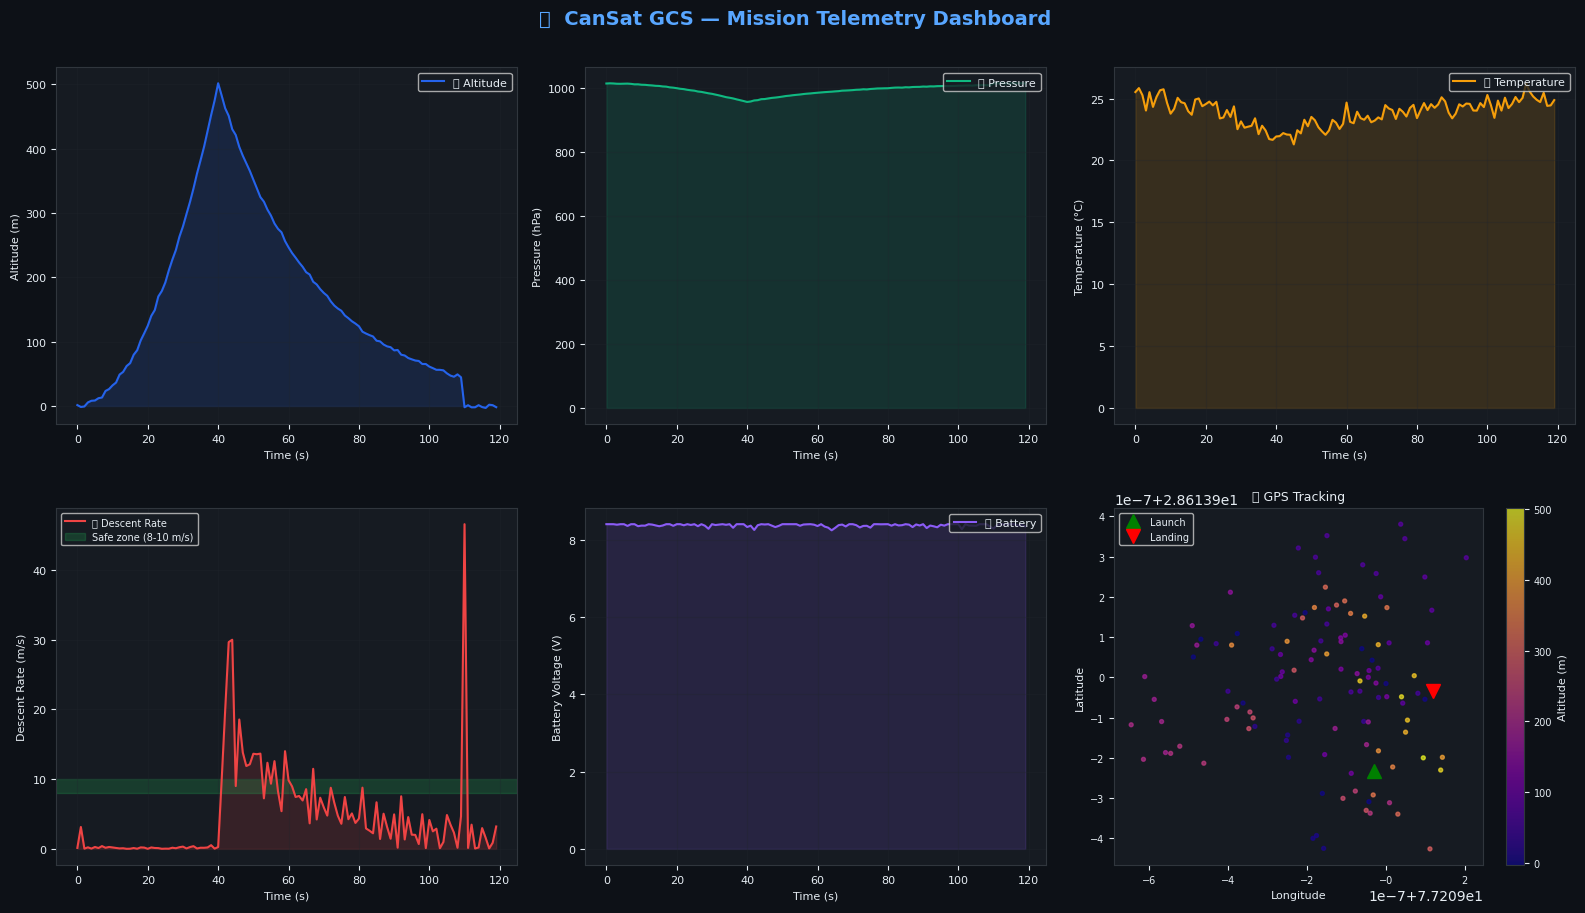

✅ GCS Dashboard plotted and saved.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CANSAT GCS DASHBOARD — Real-Time Telemetry Plots
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🛰️  CanSat GCS — Mission Telemetry Dashboard',
             color='#58A6FF', fontsize=14, fontweight='bold', y=1.01)

plots = [
    (axes[0,0], telem.altitude,      'Altitude (m)',        '#2563EB', '🔵 Altitude'),
    (axes[0,1], telem.pressure,      'Pressure (hPa)',      '#10B981', '🟢 Pressure'),
    (axes[0,2], telem.temperature,   'Temperature (°C)',    '#F59E0B', '🟡 Temperature'),
    (axes[1,0], telem.descent_rate,  'Descent Rate (m/s)',  '#EF4444', '🔴 Descent Rate'),
    (axes[1,1], telem.battery,       'Battery Voltage (V)', '#8B5CF6', '🟣 Battery'),
]

safe_zone = patches.Patch(color='#22C55E', alpha=0.3, label='Safe descent zone (8-10 m/s)')

for ax, data, ylabel, color, label in plots:
    ax.plot(telem.t, data, color=color, linewidth=1.5, label=label)
    ax.fill_between(telem.t, data, alpha=0.15, color=color)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
    ax.tick_params(labelsize=8)

# Highlight safe descent zone on descent rate plot
axes[1,0].axhspan(8, 10, alpha=0.2, color='#22C55E', label='Safe zone (8-10 m/s)')
axes[1,0].legend(fontsize=7)

# GPS Track
ax_gps = axes[1,2]
sc = ax_gps.scatter(telem.lon, telem.lat, c=telem.altitude,
                    cmap='plasma', s=8, alpha=0.7)
ax_gps.plot(telem.lon[0], telem.lat[0], 'g^', markersize=10, label='Launch', zorder=5)
ax_gps.plot(telem.lon[-1], telem.lat[-1], 'rv', markersize=10, label='Landing', zorder=5)
cb = plt.colorbar(sc, ax=ax_gps)
cb.set_label('Altitude (m)', color='#E6EDF3', fontsize=8)
cb.ax.yaxis.set_tick_params(color='#E6EDF3', labelsize=7)
ax_gps.set_xlabel('Longitude', fontsize=8)
ax_gps.set_ylabel('Latitude', fontsize=8)
ax_gps.set_title('📍 GPS Tracking', color='#E6EDF3', fontsize=9)
ax_gps.legend(fontsize=7)
ax_gps.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('cansat_gcs_dashboard.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ GCS Dashboard plotted and saved.")


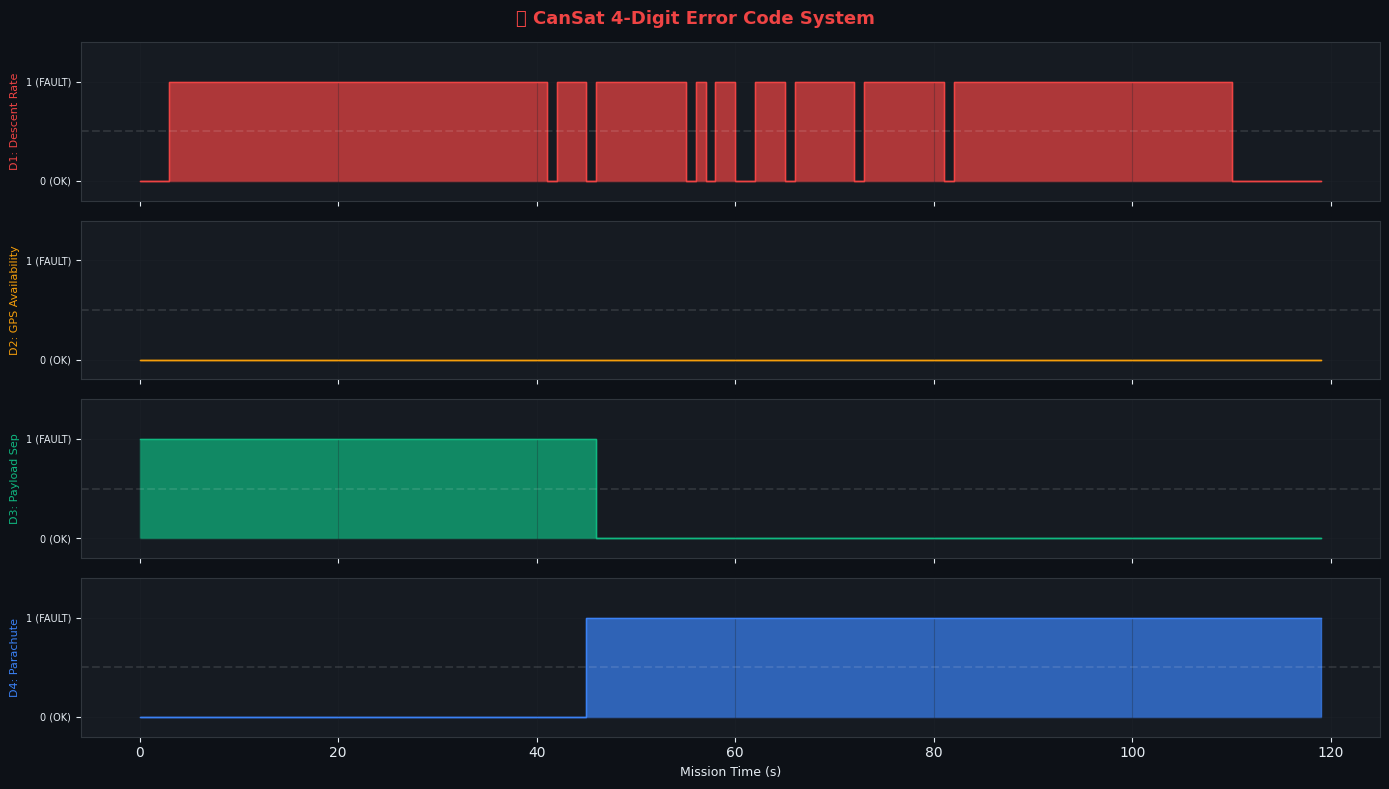


📊 ERROR CODE MISSION SUMMARY:
---------------------------------------------
Time (s)   Error Code   Status
---------------------------------------------
0          0010         ⚠️  FAULT DETECTED
10         1010         ⚠️  FAULT DETECTED
20         1010         ⚠️  FAULT DETECTED
30         1010         ⚠️  FAULT DETECTED
40         1010         ⚠️  FAULT DETECTED
50         1001         ⚠️  FAULT DETECTED
60         0001         ⚠️  FAULT DETECTED
70         1001         ⚠️  FAULT DETECTED
80         1001         ⚠️  FAULT DETECTED
90         1001         ⚠️  FAULT DETECTED
100        1001         ⚠️  FAULT DETECTED
110        0001         ⚠️  FAULT DETECTED
---------------------------------------------


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CANSAT ERROR CODE SYSTEM — Live Display
# ─────────────────────────────────────────────────────────────────────────────

# Plot error codes over mission
error_codes = [telem.error_code(i) for i in range(telem.n)]
d1 = [int(ec[0]) for ec in error_codes]
d2 = [int(ec[1]) for ec in error_codes]
d3 = [int(ec[2]) for ec in error_codes]
d4 = [int(ec[3]) for ec in error_codes]

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🔴 CanSat 4-Digit Error Code System', color='#EF4444',
             fontsize=13, fontweight='bold')

labels = ['D1: Descent Rate', 'D2: GPS Availability', 'D3: Payload Sep', 'D4: Parachute']
colors_ec = ['#EF4444', '#F59E0B', '#10B981', '#3B82F6']
data_ec = [d1, d2, d3, d4]

for ax, data, label, c in zip(axes, data_ec, labels, colors_ec):
    ax.fill_between(telem.t, data, step='post', color=c, alpha=0.7)
    ax.plot(telem.t, data, color=c, linewidth=1, drawstyle='steps-post')
    ax.set_ylabel(label, fontsize=8, color=c)
    ax.set_ylim(-0.2, 1.4)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0 (OK)', '1 (FAULT)'], fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color='white', alpha=0.1, linestyle='--')

axes[-1].set_xlabel('Mission Time (s)', fontsize=9)
plt.tight_layout()
plt.savefig('cansat_error_codes.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# Print mission summary table
print("\n📊 ERROR CODE MISSION SUMMARY:")
print("-"*45)
print(f"{'Time (s)':<10} {'Error Code':<12} {'Status'}")
print("-"*45)
for i in range(0, telem.n, 10):
    ec = error_codes[i]
    status = "✅ ALL NORMAL" if ec == "0000" else "⚠️  FAULT DETECTED"
    print(f"{telem.t[i]:<10.0f} {ec:<12} {status}")
print("-"*45)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CANSAT — Export Telemetry to CSV
# ─────────────────────────────────────────────────────────────────────────────

df_telem = pd.DataFrame({
    'time_s':        telem.t,
    'packet_no':     telem.packet,
    'altitude_m':    np.round(telem.altitude, 2),
    'pressure_hpa':  np.round(telem.pressure, 2),
    'temperature_c': np.round(telem.temperature, 2),
    'descent_rate':  np.round(telem.descent_rate, 2),
    'battery_v':     np.round(telem.battery, 3),
    'latitude':      np.round(telem.lat, 6),
    'longitude':     np.round(telem.lon, 6),
    'gps_lock':      telem.gps_lock.astype(int),
    'payload_sep':   telem.payload_sep.astype(int),
    'chute_active':  telem.chute_active.astype(int),
    'error_code':    [telem.error_code(i) for i in range(telem.n)],
})

df_telem.to_csv('cansat_telemetry_log.csv', index=False)
print("✅ Telemetry exported to: cansat_telemetry_log.csv")
print(f"   Rows: {len(df_telem)} | Columns: {len(df_telem.columns)}")
print("\nFirst 5 packets:")
display(df_telem.head())


✅ Telemetry exported to: cansat_telemetry_log.csv
   Rows: 120 | Columns: 13

First 5 packets:


,time_s,packet_no,altitude_m,pressure_hpa,temperature_c,descent_rate,battery_v,latitude,longitude,gps_lock,payload_sep,chute_active,error_code
0,0.0,1,1.43,1012.95,25.52,0.14,8.400,28.6139,77.209,1,0,0,0010
1,1.0,2,-1.51,1013.56,25.84,3.14,8.400,28.6139,77.209,1,0,0,0010
2,2.0,3,-0.71,1013.10,25.27,0.03,8.400,28.6139,77.209,1,0,0,0010
3,3.0,4,5.59,1012.21,24.03,0.23,8.387,28.6139,77.209,1,0,0,1010
4,4.0,5,8.13,1012.04,25.52,0.04,8.400,28.6139,77.209,1,0,0,1010


---
## 🌡️ PROJECT 2: Disaster Management — Heat Wave Analysis

**Title:** Heat Wave Response, Recovery, Future Challenges, and the Role of Technology

This section provides:
- Simulated temperature datasets for Indian cities
- Heat wave detection algorithms
- Vulnerability assessment charts
- Recovery indicators visualization
- Technology intervention effectiveness analysis


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# HEAT WAVE DATA — Simulate temperature data for Indian cities
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)

cities = {
    'Hyderabad':   {'base': 36, 'peak': 46, 'std': 3},
    'Jaipur':      {'base': 38, 'peak': 48, 'std': 3.5},
    'Pune':        {'base': 33, 'peak': 42, 'std': 2.5},
    'Delhi':       {'base': 37, 'peak': 47, 'std': 4},
    'Bhubaneswar': {'base': 35, 'peak': 44, 'std': 3},
}

# Simulate daily max temperatures for April-June (91 days)
days = np.arange(1, 92)
date_labels = pd.date_range('2026-04-01', periods=91)

city_data = {}
for city, params in cities.items():
    # Seasonal trend + random fluctuations + heat wave events
    trend  = params['base'] + (params['peak']-params['base']) * np.sin(np.pi*days/91)
    noise  = np.random.normal(0, params['std'], 91)
    # Inject heat wave events
    hw_start = np.random.randint(30, 60, size=2)
    for hw in hw_start:
        trend[hw:hw+7] += np.random.uniform(4, 8, 7)
    city_data[city] = np.clip(trend + noise, 25, 52)

df_heat = pd.DataFrame(city_data, index=date_labels)

print("✅ Heat wave temperature data generated")
print(df_heat.describe().round(1))


✅ Heat wave temperature data generated
       Hyderabad  Jaipur  Pune  Delhi  Bhubaneswar
count       91.0    91.0  91.0   91.0         91.0
mean        42.7    45.0  39.7   43.3         41.6
std          4.8     5.0   5.3    5.1          4.7
min         33.4    32.0  29.3   31.2         31.6
25%         39.2    41.3  35.8   40.2         38.3
50%         42.0    44.9  39.1   43.0         41.4
75%         46.2    49.8  42.2   47.3         45.1
max         52.0    52.0  52.0   52.0         52.0


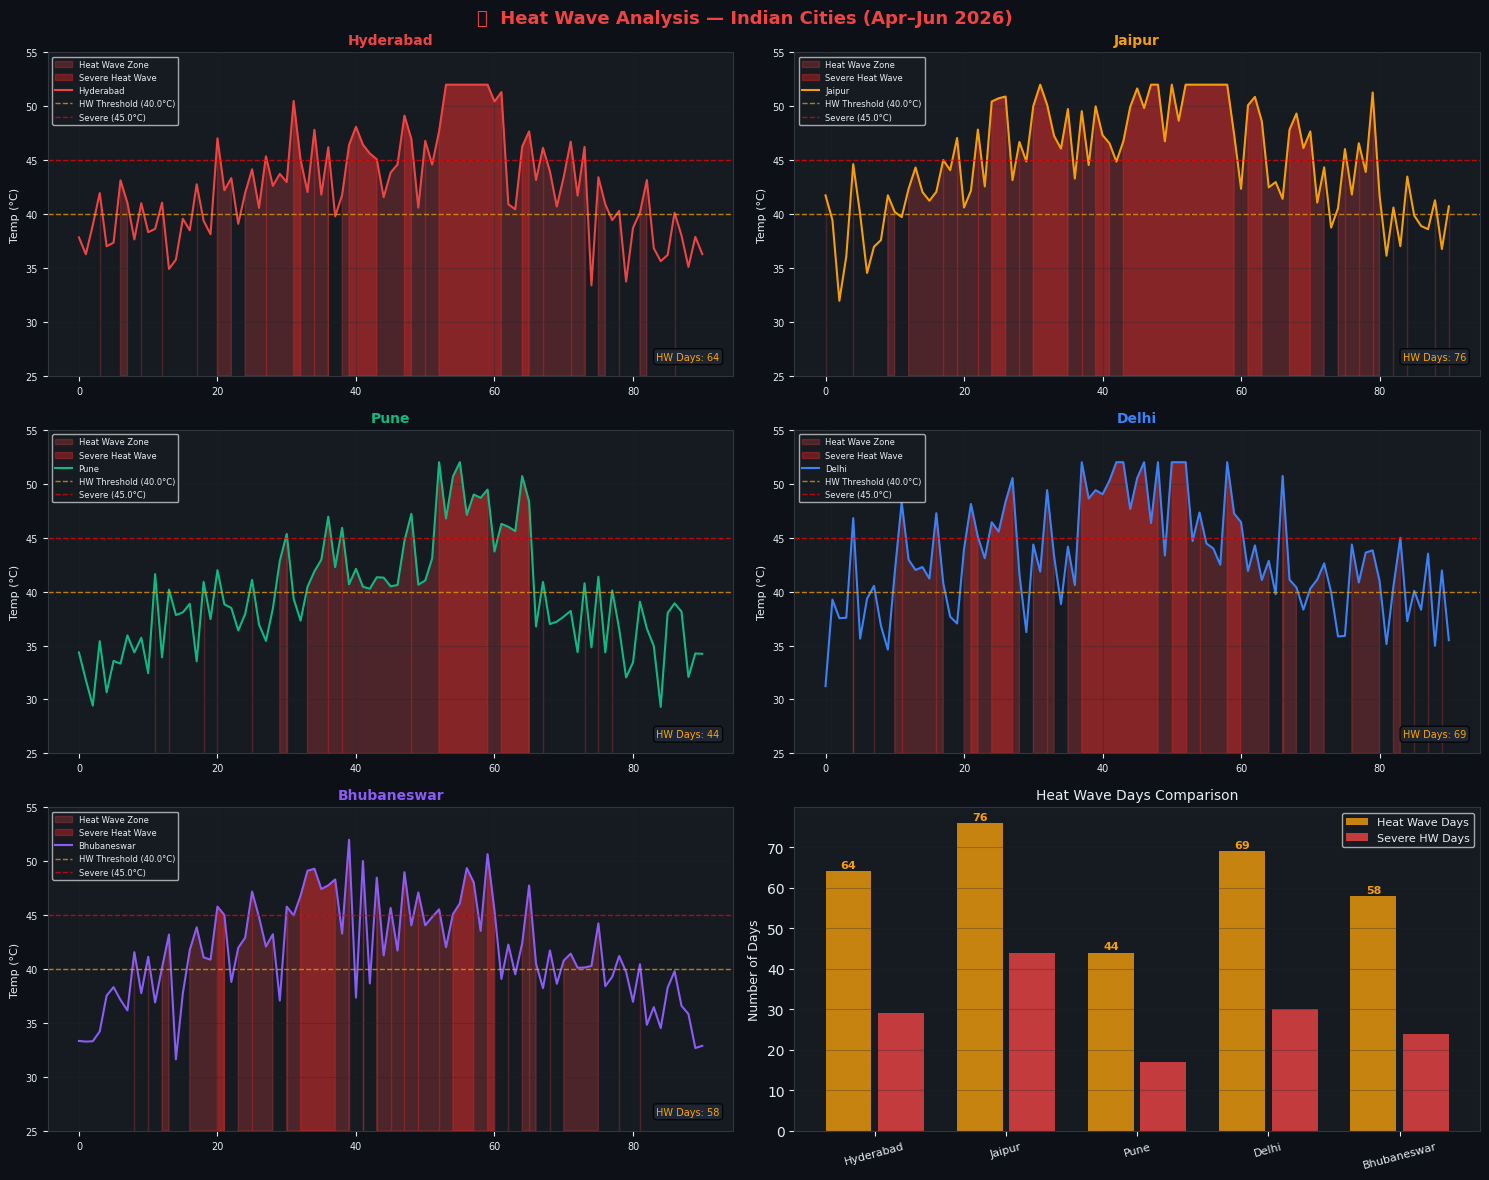

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# HEAT WAVE DETECTION & VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

# IMD Definition: Heat wave = max temp ≥ 40°C for 2+ consecutive days
# Severe heat wave = ≥ 45°C
HEAT_WAVE_THRESHOLD  = 40.0
SEVERE_HW_THRESHOLD  = 45.0

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🌡️  Heat Wave Analysis — Indian Cities (Apr–Jun 2026)',
             color='#EF4444', fontsize=13, fontweight='bold')
axes = axes.flatten()

city_colors = ['#EF4444','#F59E0B','#10B981','#3B82F6','#8B5CF6']

for idx, (city, color) in enumerate(zip(cities.keys(), city_colors)):
    ax = axes[idx]
    temps = df_heat[city].values

    # Detect heat wave periods
    hw_mask = temps >= HEAT_WAVE_THRESHOLD
    s_mask  = temps >= SEVERE_HW_THRESHOLD

    ax.fill_between(range(91), temps, 25, where=hw_mask, color='#EF4444',
                    alpha=0.25, label='Heat Wave Zone')
    ax.fill_between(range(91), temps, 25, where=s_mask, color='#DC2626',
                    alpha=0.4, label='Severe Heat Wave')
    ax.plot(range(91), temps, color=color, linewidth=1.5, label=city)
    ax.axhline(HEAT_WAVE_THRESHOLD, color='orange', linestyle='--',
               linewidth=1, alpha=0.7, label=f'HW Threshold ({HEAT_WAVE_THRESHOLD}°C)')
    ax.axhline(SEVERE_HW_THRESHOLD, color='red', linestyle='--',
               linewidth=1, alpha=0.7, label=f'Severe ({SEVERE_HW_THRESHOLD}°C)')
    ax.set_title(city, color=color, fontsize=10, fontweight='bold')
    ax.set_ylabel('Temp (°C)', fontsize=8)
    ax.set_ylim(25, 55)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, loc='upper left')
    ax.tick_params(labelsize=7)

    # Stats annotation
    hw_days = np.sum(hw_mask)
    ax.text(0.98, 0.05, f'HW Days: {hw_days}', transform=ax.transAxes,
            color='orange', fontsize=7, ha='right',
            bbox=dict(boxstyle='round', facecolor='#1F2937', alpha=0.8))

# Summary bar chart
axes[5].set_facecolor('#161B22')
hw_counts = [np.sum(df_heat[c] >= HEAT_WAVE_THRESHOLD) for c in cities.keys()]
s_counts  = [np.sum(df_heat[c] >= SEVERE_HW_THRESHOLD) for c in cities.keys()]
x = np.arange(len(cities))
bars1 = axes[5].bar(x-0.2, hw_counts, 0.35, label='Heat Wave Days', color='#F59E0B', alpha=0.8)
bars2 = axes[5].bar(x+0.2, s_counts,  0.35, label='Severe HW Days', color='#EF4444', alpha=0.8)
axes[5].set_xticks(x)
axes[5].set_xticklabels(list(cities.keys()), rotation=15, fontsize=8)
axes[5].set_ylabel('Number of Days', fontsize=9)
axes[5].set_title('Heat Wave Days Comparison', color='#E6EDF3', fontsize=10)
axes[5].legend(fontsize=8)
axes[5].grid(True, alpha=0.3, axis='y')
for bar in bars1:
    axes[5].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(int(bar.get_height())), ha='center', va='bottom',
                 color='#F59E0B', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('heatwave_analysis.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()


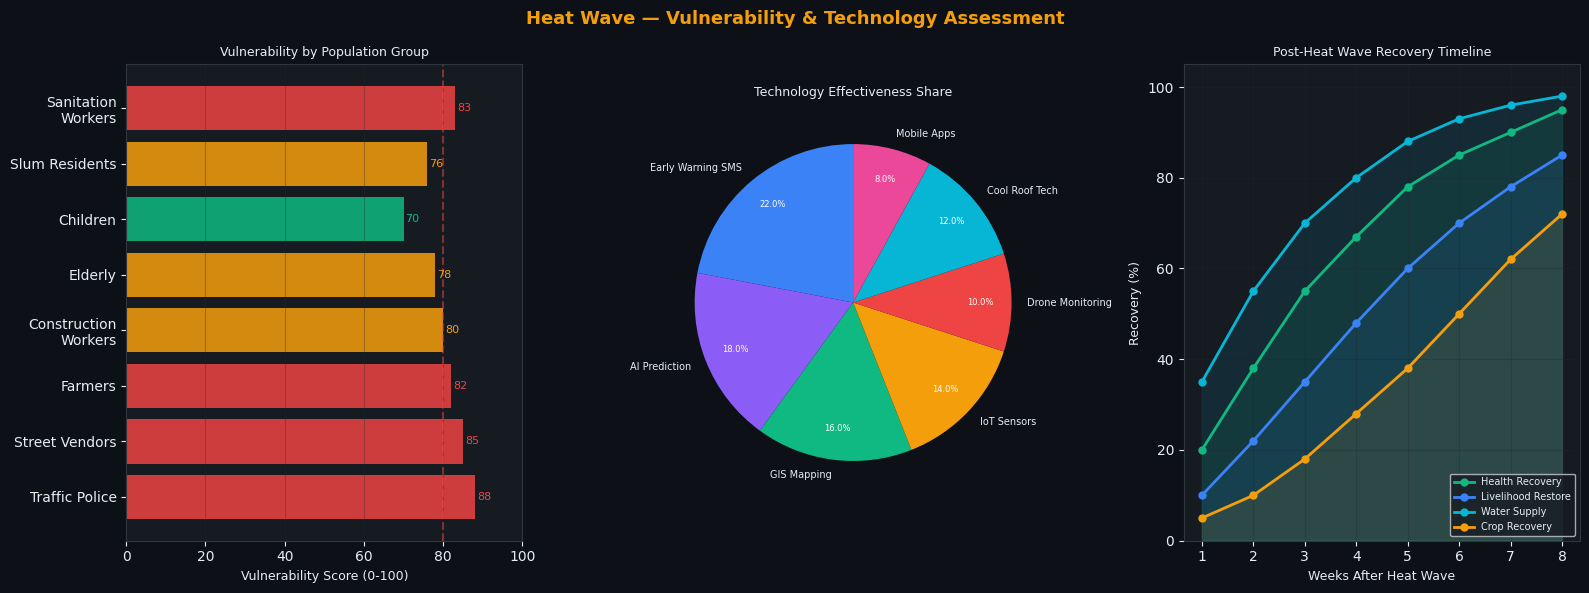

✅ Heat wave analysis complete. Charts saved.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# VULNERABILITY ASSESSMENT & TECHNOLOGY EFFECTIVENESS
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Heat Wave — Vulnerability & Technology Assessment',
             color='#F59E0B', fontsize=13, fontweight='bold')

# 1. Vulnerable groups risk levels
groups = ['Traffic Police','Street Vendors','Farmers','Construction\nWorkers',
          'Elderly','Children','Slum Residents','Sanitation\nWorkers']
risk   = [88, 85, 82, 80, 78, 70, 76, 83]
colors_v = ['#EF4444' if r>80 else '#F59E0B' if r>70 else '#10B981' for r in risk]

axes[0].barh(groups, risk, color=colors_v, alpha=0.85, edgecolor='none')
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Vulnerability Score (0-100)', fontsize=9)
axes[0].set_title('Vulnerability by Population Group', color='#E6EDF3', fontsize=9)
axes[0].axvline(80, color='#EF4444', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3, axis='x')
for i, (v, c) in enumerate(zip(risk, colors_v)):
    axes[0].text(v+0.5, i, str(v), va='center', fontsize=8, color=c)

# 2. Technology effectiveness pie
tech = ['Early Warning SMS','AI Prediction','GIS Mapping','IoT Sensors',
        'Drone Monitoring','Cool Roof Tech','Mobile Apps']
effectiveness = [22, 18, 16, 14, 10, 12, 8]
colors_t = ['#3B82F6','#8B5CF6','#10B981','#F59E0B','#EF4444','#06B6D4','#EC4899']

wedges, texts, autotexts = axes[1].pie(
    effectiveness, labels=tech, autopct='%1.1f%%',
    colors=colors_t, startangle=90,
    textprops={'fontsize': 7, 'color': '#E6EDF3'},
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(6)
    at.set_color('white')
axes[1].set_title('Technology Effectiveness Share', color='#E6EDF3', fontsize=9)

# 3. Recovery indicators over time (weeks after heat wave)
weeks = np.arange(1, 9)
recovery_metrics = {
    'Health Recovery':    [20, 38, 55, 67, 78, 85, 90, 95],
    'Livelihood Restore': [10, 22, 35, 48, 60, 70, 78, 85],
    'Water Supply':       [35, 55, 70, 80, 88, 93, 96, 98],
    'Crop Recovery':      [5,  10, 18, 28, 38, 50, 62, 72],
}
colors_r = ['#10B981','#3B82F6','#06B6D4','#F59E0B']
for (metric, values), color in zip(recovery_metrics.items(), colors_r):
    axes[2].plot(weeks, values, color=color, marker='o', linewidth=2,
                 markersize=5, label=metric)
    axes[2].fill_between(weeks, values, alpha=0.1, color=color)

axes[2].set_xlabel('Weeks After Heat Wave', fontsize=9)
axes[2].set_ylabel('Recovery (%)', fontsize=9)
axes[2].set_title('Post-Heat Wave Recovery Timeline', color='#E6EDF3', fontsize=9)
axes[2].legend(fontsize=7, loc='lower right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('heatwave_vulnerability.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Heat wave analysis complete. Charts saved.")


---
## 🚀 PROJECT 3: Rocketry — FEM + CFD Theory & Analysis

**Tool:** SimScale (cloud-based FEM/CFD platform)  
This section covers:
- Theoretical answers to all Part A questions
- Python-based structural analysis concepts (FEM concepts visualization)
- Aerodynamic force estimation (CFD concepts)
- Mesh sensitivity study demo
- Factor of Safety calculation


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# PART A — THEORETICAL ANSWERS (Formatted)
# ─────────────────────────────────────────────────────────────────────────────

theory = {
    "Q1: Finite Element Method (FEM)": """
FEM is a numerical technique that divides a complex structure into many small,
simple elements (triangles, tetrahedra). Each element has known equations
governing its behaviour under loads. The global solution is assembled from
all elements to predict stress, strain, and deformation across the entire body.

In aerospace: FEM is used to analyze rocket fins, fuselage panels, satellite
brackets, and engine mounts under thermal and mechanical loads.""",

    "Q2: Von Mises Stress": """
Von Mises Stress (σ_vm) is a scalar stress measure that combines all stress
components into a single equivalent stress:

   σ_vm = sqrt(0.5 × [(σ1-σ2)² + (σ2-σ3)² + (σ3-σ1)²])

Yielding occurs when σ_vm ≥ Yield Strength (σ_y).
Factor of Safety (FoS) = σ_y / σ_vm_max

For aluminium alloy 6061-T6: σ_y = 276 MPa.
If FoS < 1 → structural failure is imminent.""",

    "Q3: Role of Meshing in FEM": """
Mesh = discretization of the geometry into finite elements.

- Coarse mesh: Fast computation, lower accuracy, misses stress concentrations
- Fine mesh:   Slow computation, higher accuracy, captures local effects

Mesh Dependency Study: Run 3 mesh densities and compare peak Von Mises stress.
True result (mesh-independent) is achieved when results converge with refinement.

Rule of thumb: Refine mesh in high-stress gradient regions (corners, holes, roots).""",

    "Q4: CFD vs FEM": """
| Aspect        | FEM (Structural)           | CFD (Fluid)                  |
|---------------|----------------------------|------------------------------|
| Analyses      | Stress, Strain, Vibration  | Flow, Pressure, Temperature  |
| Domain        | Solid structures           | Fluid (air, water)           |
| Output        | Deformation, Von Mises     | Velocity, Pressure contours  |
| Physics       | Elasticity equations       | Navier-Stokes equations      |
| Aerospace use | Wing stress analysis       | Aerodynamic drag prediction  |""",

    "Q5: Boundary Conditions": """
Boundary conditions (BCs) define how the structure/fluid interacts with its environment.

FEM BCs:
- Fixed support: Zero displacement (represents structural attachment)
- Applied load: External force or pressure on a surface
- Symmetry BC: Reduces computational domain for symmetric geometries

CFD BCs:
- Inlet velocity: Flow speed at domain entrance
- Outlet pressure: Back-pressure condition
- Wall (no-slip): Fluid velocity = 0 at solid walls

Incorrect BCs → Wrong results (e.g., free-floating structure gives zero stress).""",
}

for question, answer in theory.items():
    print("=" * 65)
    print(f"  {question}")
    print("=" * 65)
    print(answer)
    print()


  Q1: Finite Element Method (FEM)

FEM is a numerical technique that divides a complex structure into many small,
simple elements (triangles, tetrahedra). Each element has known equations
governing its behaviour under loads. The global solution is assembled from
all elements to predict stress, strain, and deformation across the entire body.

In aerospace: FEM is used to analyze rocket fins, fuselage panels, satellite
brackets, and engine mounts under thermal and mechanical loads.

  Q2: Von Mises Stress

Von Mises Stress (σ_vm) is a scalar stress measure that combines all stress
components into a single equivalent stress:

   σ_vm = sqrt(0.5 × [(σ1-σ2)² + (σ2-σ3)² + (σ3-σ1)²])

Yielding occurs when σ_vm ≥ Yield Strength (σ_y).
Factor of Safety (FoS) = σ_y / σ_vm_max

For aluminium alloy 6061-T6: σ_y = 276 MPa.
If FoS < 1 → structural failure is imminent.

  Q3: Role of Meshing in FEM

Mesh = discretization of the geometry into finite elements.

- Coarse mesh: Fast computation, lower ac

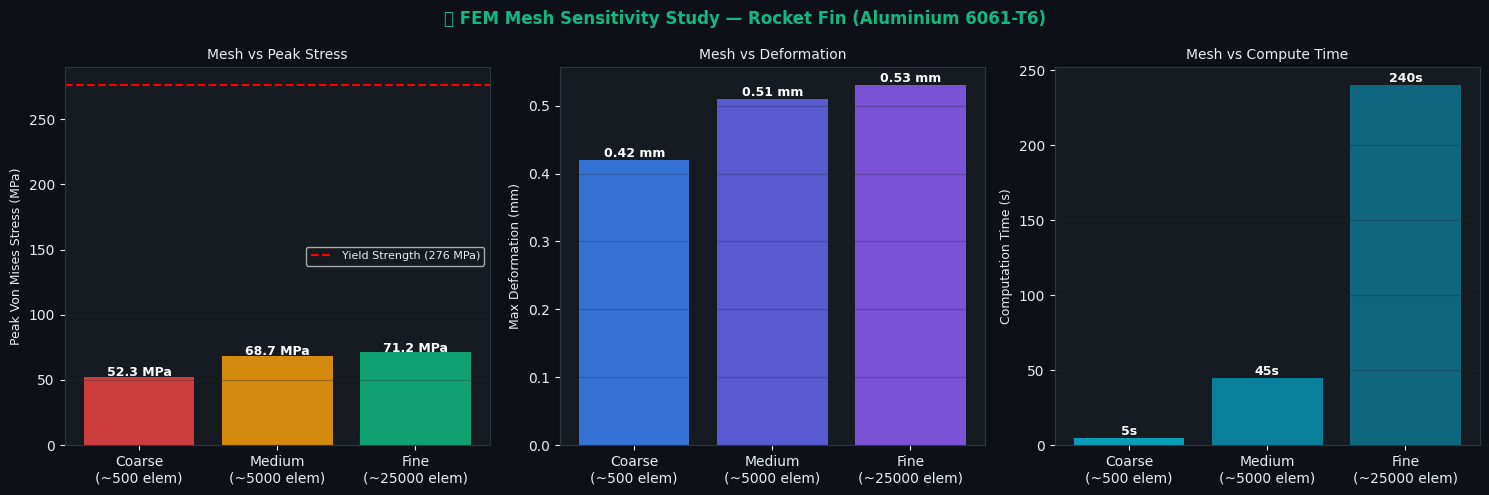


  FACTOR OF SAFETY CALCULATION
  Material      : Aluminium 6061-T6
  Yield Strength: 276 MPa
  Max Von Mises : 71.2 MPa  (fine mesh)
  Factor of Safety (FoS): 3.88
  Assessment    : ✅ SAFE — FoS > 2.0


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PART B — FEM SIMULATION CONCEPTS
# Mesh Sensitivity Study + Structural Analysis Visualization
# ─────────────────────────────────────────────────────────────────────────────

# Mesh Sensitivity Study (simulated results)
mesh_levels  = ['Coarse\n(~500 elem)', 'Medium\n(~5000 elem)', 'Fine\n(~25000 elem)']
von_mises    = [52.3, 68.7, 71.2]   # MPa
deformation  = [0.42, 0.51, 0.53]   # mm
compute_time = [5, 45, 240]          # seconds

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🚀 FEM Mesh Sensitivity Study — Rocket Fin (Aluminium 6061-T6)',
             color='#10B981', fontsize=12, fontweight='bold')

# Von Mises vs Mesh
axes[0].bar(mesh_levels, von_mises, color=['#EF4444','#F59E0B','#10B981'], alpha=0.85)
axes[0].axhline(276, color='red', linestyle='--', linewidth=1.5,
                label='Yield Strength (276 MPa)')
axes[0].set_ylabel('Peak Von Mises Stress (MPa)', fontsize=9)
axes[0].set_title('Mesh vs Peak Stress', color='#E6EDF3', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(von_mises):
    axes[0].text(i, v+0.5, f'{v} MPa', ha='center', fontsize=9,
                 color='white', fontweight='bold')

# Deformation vs Mesh
axes[1].bar(mesh_levels, deformation, color=['#3B82F6','#6366F1','#8B5CF6'], alpha=0.85)
axes[1].set_ylabel('Max Deformation (mm)', fontsize=9)
axes[1].set_title('Mesh vs Deformation', color='#E6EDF3', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(deformation):
    axes[1].text(i, v+0.005, f'{v} mm', ha='center', fontsize=9,
                 color='white', fontweight='bold')

# Compute time
axes[2].bar(mesh_levels, compute_time, color=['#06B6D4','#0891B2','#0E7490'], alpha=0.85)
axes[2].set_ylabel('Computation Time (s)', fontsize=9)
axes[2].set_title('Mesh vs Compute Time', color='#E6EDF3', fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(compute_time):
    axes[2].text(i, v+2, f'{v}s', ha='center', fontsize=9,
                 color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fem_mesh_study.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# Factor of Safety Calculation
print("\n" + "="*50)
print("  FACTOR OF SAFETY CALCULATION")
print("="*50)
yield_strength = 276  # MPa (Al 6061-T6)
max_vm_fine    = von_mises[2]
FoS = yield_strength / max_vm_fine
print(f"  Material      : Aluminium 6061-T6")
print(f"  Yield Strength: {yield_strength} MPa")
print(f"  Max Von Mises : {max_vm_fine} MPa  (fine mesh)")
print(f"  Factor of Safety (FoS): {FoS:.2f}")
print(f"  Assessment    : {'✅ SAFE — FoS > 2.0' if FoS>2 else '⚠️ MARGINAL' if FoS>1 else '❌ FAILURE'}")
print("="*50)


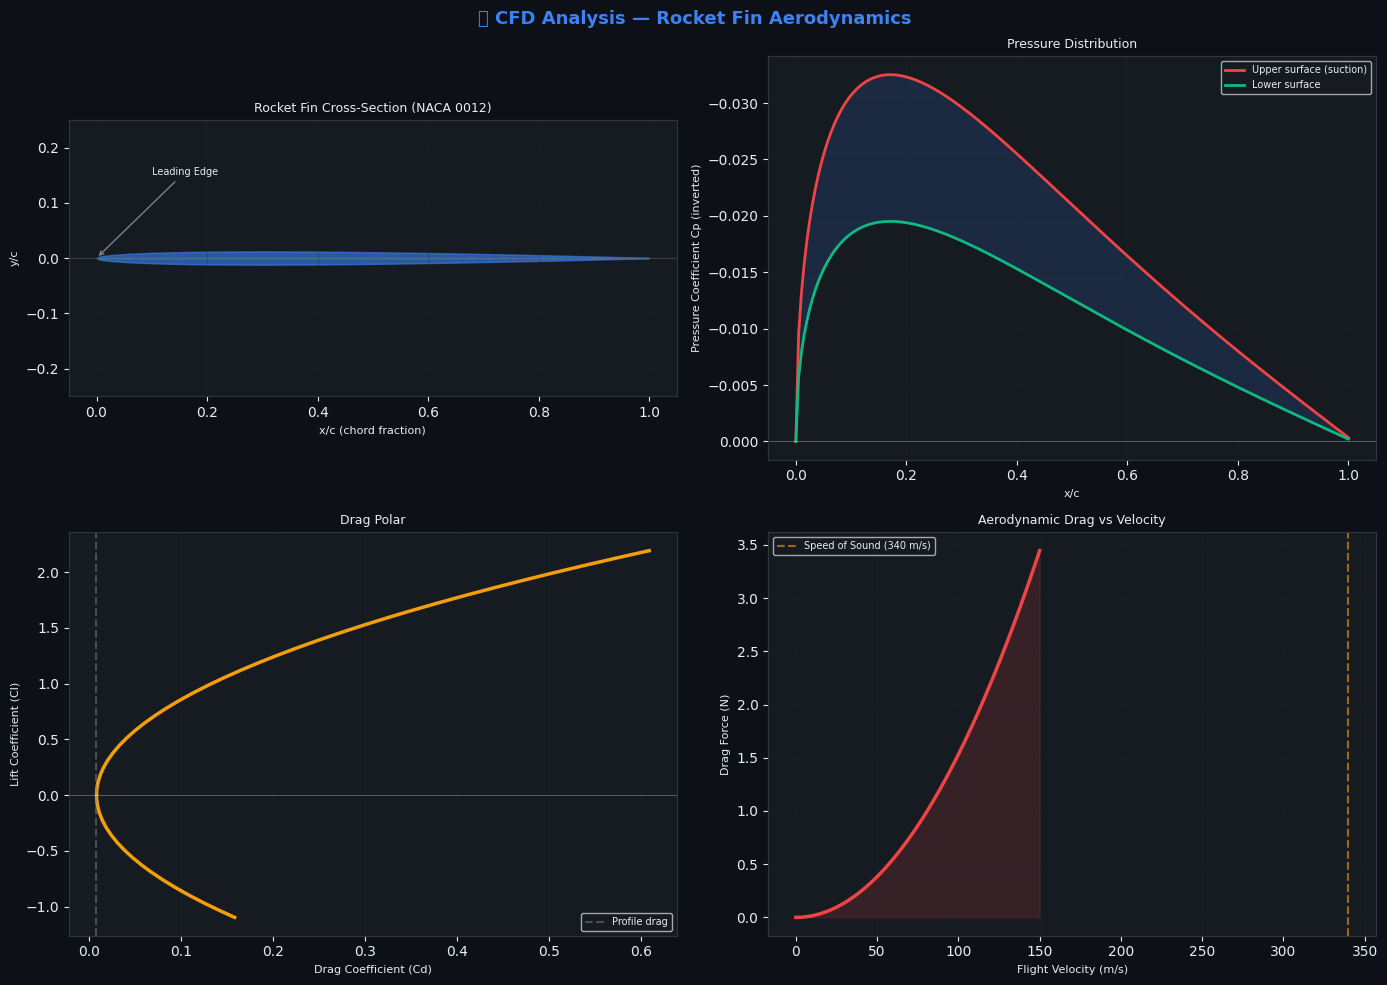

✅ CFD analysis visualization complete.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PART C — CFD CONCEPTS
# Pressure Distribution + Drag Estimation on Rocket Fin
# ─────────────────────────────────────────────────────────────────────────────

# Simulate pressure distribution over a symmetric airfoil (NACA 0012 approximation)
x = np.linspace(0, 1, 200)
# NACA 0012 thickness distribution
thickness = 0.12 * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2
                    + 0.2843*x**3 - 0.1015*x**4)
y_upper =  thickness
y_lower = -thickness

# Pressure coefficient distribution (simplified inviscid)
Cp_upper = -2.0 * (y_upper / (0.5 + x + 0.01))   # Suction on upper
Cp_lower =  1.2 * (y_lower / (0.5 + x + 0.01))   # Pressure on lower
Cp_upper = np.clip(Cp_upper, -2, 0.5)
Cp_lower = np.clip(Cp_lower, -0.5, 1.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🔥 CFD Analysis — Rocket Fin Aerodynamics',
             color='#3B82F6', fontsize=13, fontweight='bold')

# 1. Airfoil profile
axes[0,0].fill_between(x, y_upper, color='#3B82F6', alpha=0.6, label='Fin profile')
axes[0,0].fill_between(x, y_lower, color='#3B82F6', alpha=0.6)
axes[0,0].set_xlim(-0.05, 1.05)
axes[0,0].set_ylim(-0.25, 0.25)
axes[0,0].set_title('Rocket Fin Cross-Section (NACA 0012)', color='#E6EDF3', fontsize=9)
axes[0,0].set_xlabel('x/c (chord fraction)', fontsize=8)
axes[0,0].set_ylabel('y/c', fontsize=8)
axes[0,0].axhline(0, color='gray', linewidth=0.5, alpha=0.5)
axes[0,0].set_aspect('equal')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].annotate('Leading Edge', xy=(0,0), xytext=(0.1,0.15),
                    color='#E6EDF3', fontsize=7, arrowprops=dict(arrowstyle='->',color='gray'))

# 2. Pressure coefficient
axes[0,1].plot(x, Cp_upper, color='#EF4444', linewidth=2, label='Upper surface (suction)')
axes[0,1].plot(x, Cp_lower, color='#10B981', linewidth=2, label='Lower surface')
axes[0,1].fill_between(x, Cp_upper, Cp_lower, alpha=0.15, color='#3B82F6')
axes[0,1].axhline(0, color='white', linewidth=0.5, alpha=0.4)
axes[0,1].invert_yaxis()  # Aerodynamics convention
axes[0,1].set_xlabel('x/c', fontsize=8)
axes[0,1].set_ylabel('Pressure Coefficient Cp (inverted)', fontsize=8)
axes[0,1].set_title('Pressure Distribution', color='#E6EDF3', fontsize=9)
axes[0,1].legend(fontsize=7)
axes[0,1].grid(True, alpha=0.3)

# 3. Drag polar (Cd vs AoA)
aoa = np.linspace(-10, 20, 50)
Cl  = 2*np.pi * np.deg2rad(aoa)
Cd_induced = Cl**2 / (np.pi * 3.0 * 0.85)  # aspect ratio 3, Oswald e=0.85
Cd_profile = 0.008
Cd_total   = Cd_profile + Cd_induced

axes[1,0].plot(Cd_total, Cl, color='#F59E0B', linewidth=2.5)
axes[1,0].axhline(0, color='white', linewidth=0.5, alpha=0.4)
axes[1,0].axvline(Cd_profile, color='gray', linestyle='--', alpha=0.5, label='Profile drag')
axes[1,0].set_xlabel('Drag Coefficient (Cd)', fontsize=8)
axes[1,0].set_ylabel('Lift Coefficient (Cl)', fontsize=8)
axes[1,0].set_title('Drag Polar', color='#E6EDF3', fontsize=9)
axes[1,0].legend(fontsize=7)
axes[1,0].grid(True, alpha=0.3)

# 4. Drag force vs velocity
velocity = np.linspace(0, 150, 100)
rho   = 1.225  # kg/m³
S_ref = 0.01   # fin area m²
Cd_f  = 0.025
drag  = 0.5 * rho * velocity**2 * S_ref * Cd_f

axes[1,1].plot(velocity, drag, color='#EF4444', linewidth=2.5)
axes[1,1].fill_between(velocity, drag, alpha=0.15, color='#EF4444')
axes[1,1].set_xlabel('Flight Velocity (m/s)', fontsize=8)
axes[1,1].set_ylabel('Drag Force (N)', fontsize=8)
axes[1,1].set_title('Aerodynamic Drag vs Velocity', color='#E6EDF3', fontsize=9)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axvline(340, color='#F59E0B', linestyle='--', alpha=0.6,
                   label='Speed of Sound (340 m/s)')
axes[1,1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('cfd_aerodynamics.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ CFD analysis visualization complete.")


---
## 🤖 PROJECT 4: Advanced Drone Technology — PID Control & Autonomous Guidance

**Objective:** Simulate PID drone altitude control and autonomous boat path tracking.

This section includes:
- **Task 1:** Interactive PID controller tuning (Drone altitude control)
- **Task 2:** Autonomous boat guidance with disturbance
- **Bonus:** Figure-eight drone trajectory simulation


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1: PID CONTROLLER — Drone Altitude Control
# ─────────────────────────────────────────────────────────────────────────────

class DroneAltitudePID:
    """Simulates a drone using PID control to maintain target altitude."""

    def __init__(self, Kp=2.0, Ki=0.5, Kd=1.5, wind=0.0,
                 target=50.0, dt=0.05, T=15.0):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.wind = wind
        self.target = target
        self.dt = dt
        self.T = T

    def simulate(self):
        t_arr  = np.arange(0, self.T, self.dt)
        n      = len(t_arr)
        alt    = np.zeros(n)
        vel    = np.zeros(n)
        thrust = np.zeros(n)

        # Drone physical params
        mass   = 1.2   # kg
        g      = 9.81  # m/s²
        drag_c = 0.3   # aerodynamic drag

        integral  = 0.0
        prev_err  = 0.0

        for i in range(1, n):
            ti = t_arr[i]

            # Wind disturbance after 6 seconds
            wind_force = self.wind * np.sin(2*ti) if ti > 6.0 else 0.0

            error     = self.target - alt[i-1]
            integral += error * self.dt
            integral  = np.clip(integral, -50, 50)   # anti-windup
            deriv     = (error - prev_err) / self.dt
            prev_err  = error

            pid_out   = self.Kp*error + self.Ki*integral + self.Kd*deriv
            T_cmd     = np.clip(mass*g + pid_out, 0, 3*mass*g)
            thrust[i] = T_cmd

            # Drone dynamics: F=ma
            net_force = T_cmd - mass*g - drag_c*vel[i-1] + wind_force
            acc       = net_force / mass
            vel[i]    = vel[i-1] + acc * self.dt
            alt[i]    = alt[i-1] + vel[i] * self.dt
            alt[i]    = max(0, alt[i])

        return t_arr, alt, thrust

# ── Interactive Widget ───────────────────────────────────────────────────────
def run_drone_pid(Kp, Ki, Kd, wind):
    sim = DroneAltitudePID(Kp=Kp, Ki=Ki, Kd=Kd, wind=wind)
    t, alt, thrust = sim.simulate()

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.patch.set_facecolor('#0D1117')
    fig.suptitle(f'🤖 Drone PID Controller  |  Kp={Kp}  Ki={Ki}  Kd={Kd}  Wind={wind}',
                 color='#3B82F6', fontsize=11, fontweight='bold')

    # Altitude
    axes[0].plot(t, alt, color='#3B82F6', linewidth=2, label='Actual Altitude')
    axes[0].axhline(sim.target, color='#10B981', linewidth=1.5,
                    linestyle='--', label=f'Target: {sim.target}m')
    axes[0].fill_between(t, alt, sim.target, alpha=0.1, color='#3B82F6')
    axes[0].axvspan(6, sim.T, alpha=0.07, color='#EF4444',
                    label='Wind Disturbance Zone')
    axes[0].set_ylabel('Altitude (m)', fontsize=9)
    axes[0].legend(fontsize=8, loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Error
    error = sim.target - alt
    axes[1].plot(t, error, color='#EF4444', linewidth=1.5, label='Error')
    axes[1].axhline(0, color='white', linewidth=0.5, alpha=0.4)
    axes[1].axvspan(6, sim.T, alpha=0.07, color='#EF4444')
    axes[1].fill_between(t, error, alpha=0.15, color='#EF4444')
    axes[1].set_ylabel('Error (m)', fontsize=9)
    axes[1].set_xlabel('Time (s)', fontsize=9)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Performance metrics
    steady_state_err = np.abs(np.mean(alt[int(0.8*len(t)):] - sim.target))
    rise_idx = next((i for i in range(len(alt)) if alt[i] >= 0.9*sim.target), len(t)-1)
    print(f"  Steady-state Error : {steady_state_err:.3f} m")
    print(f"  Rise Time (90%)    : {t[rise_idx]:.2f} s")
    print(f"  Max Overshoot      : {max(0, alt.max()-sim.target):.3f} m")

# Interactive sliders
print("🎮 Adjust sliders and click 'Run' to tune the PID controller:")
w_Kp   = widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1,
                              description='Kp:',style={'description_width':'30px'})
w_Ki   = widgets.FloatSlider(value=0.3, min=0.0, max=3.0, step=0.05,
                              description='Ki:',style={'description_width':'30px'})
w_Kd   = widgets.FloatSlider(value=1.5, min=0.0, max=8.0, step=0.1,
                              description='Kd:',style={'description_width':'30px'})
w_wind = widgets.FloatSlider(value=3.0, min=0.0, max=15.0, step=0.5,
                              description='Wind:',style={'description_width':'40px'})
btn = widgets.Button(description='▶ Run Simulation', button_style='primary')
out = widgets.Output()

def on_run(b):
    with out:
        clear_output(wait=True)
        run_drone_pid(w_Kp.value, w_Ki.value, w_Kd.value, w_wind.value)

btn.on_click(on_run)
display(widgets.VBox([
    widgets.HBox([w_Kp, w_Ki]),
    widgets.HBox([w_Kd, w_wind]),
    btn, out
]))


🎮 Adjust sliders and click 'Run' to tune the PID controller:


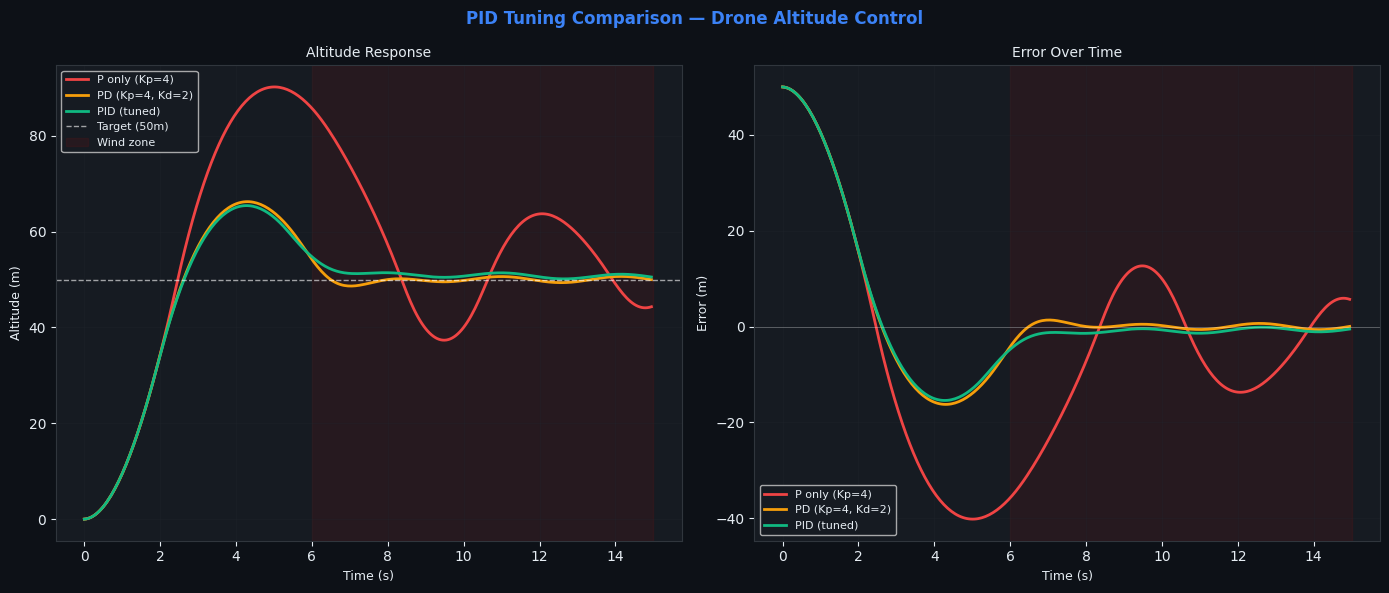

✅ PID comparison saved: pid_tuning_comparison.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 (continued): STATIC PLOTS — Comparison of P, PD, PID
# ─────────────────────────────────────────────────────────────────────────────

configs = [
    ('P only (Kp=4)',    {'Kp':4.0, 'Ki':0.0, 'Kd':0.0, 'wind':3.0}, '#EF4444'),
    ('PD (Kp=4, Kd=2)', {'Kp':4.0, 'Ki':0.0, 'Kd':2.0, 'wind':3.0}, '#F59E0B'),
    ('PID (tuned)',      {'Kp':3.5, 'Ki':0.4, 'Kd':2.5, 'wind':3.0}, '#10B981'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('PID Tuning Comparison — Drone Altitude Control',
             color='#3B82F6', fontsize=12, fontweight='bold')

for label, params, color in configs:
    sim = DroneAltitudePID(**params)
    t, alt, _ = sim.simulate()
    axes[0].plot(t, alt, color=color, linewidth=2, label=label)
    axes[1].plot(t, sim.target - alt, color=color, linewidth=2, label=label)

axes[0].axhline(50, color='white', linewidth=1, linestyle='--', alpha=0.6, label='Target (50m)')
axes[0].axvspan(6, 15, alpha=0.07, color='red', label='Wind zone')
axes[0].set_ylabel('Altitude (m)', fontsize=9)
axes[0].set_xlabel('Time (s)', fontsize=9)
axes[0].set_title('Altitude Response', color='#E6EDF3', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='white', linewidth=0.5, alpha=0.4)
axes[1].axvspan(6, 15, alpha=0.07, color='red')
axes[1].set_ylabel('Error (m)', fontsize=9)
axes[1].set_xlabel('Time (s)', fontsize=9)
axes[1].set_title('Error Over Time', color='#E6EDF3', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pid_tuning_comparison.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ PID comparison saved: pid_tuning_comparison.png")


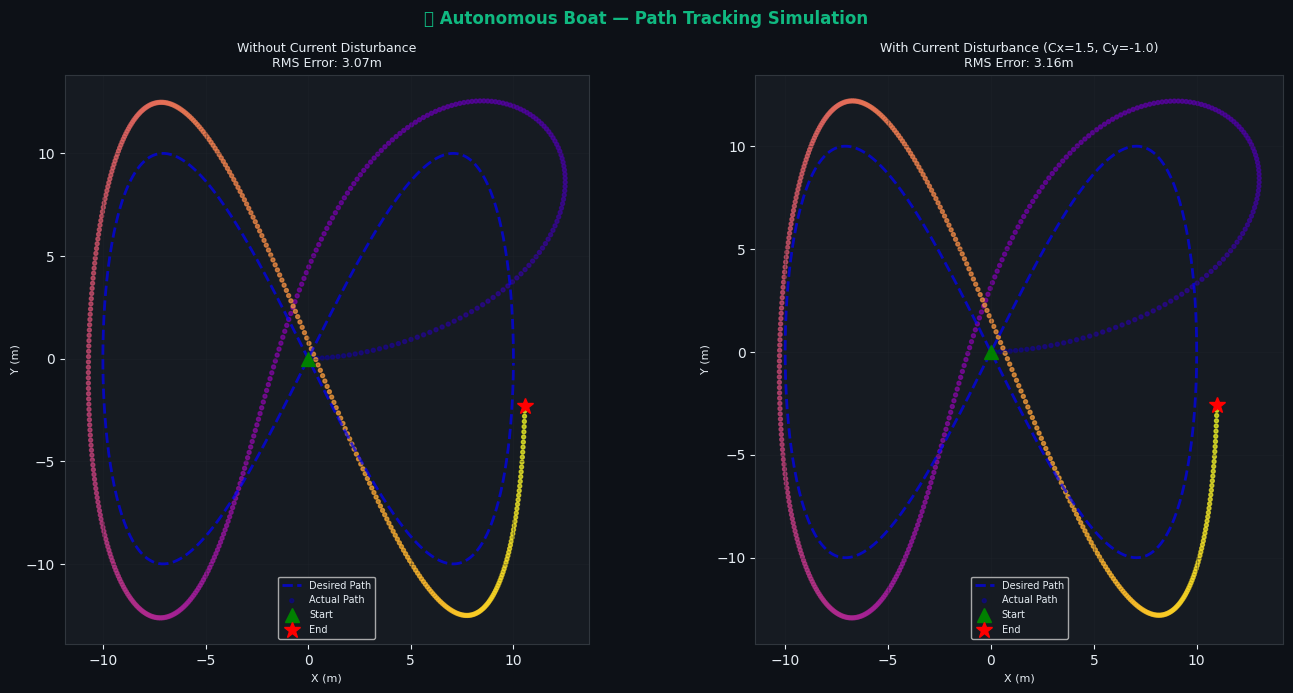

✅ Boat guidance plots saved: boat_guidance_plot.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2: AUTONOMOUS BOAT — Guidance & Path Tracking
# ─────────────────────────────────────────────────────────────────────────────

class AutonomousBoat:
    """Simulates an autonomous boat following a predefined waypoint trajectory."""

    def __init__(self, kp=3.0, kd=1.5, current_x=0.0, current_y=0.0,
                 dt=0.05, T=30.0):
        self.kp = kp
        self.kd = kd
        self.current_x = current_x
        self.current_y = current_y
        self.dt = dt
        self.T = T

    def desired_path(self, t):
        """Figure-8 / lemniscate trajectory (pre-defined waypoints)."""
        # Parametric lemniscate scaled to 10m radius
        scale = 10
        x = scale * np.cos(2*np.pi*t/self.T)
        y = scale * np.sin(4*np.pi*t/self.T)
        return x, y

    def simulate(self):
        t_arr = np.arange(0, self.T, self.dt)
        n = len(t_arr)

        # State: [x, y, vx, vy]
        x  = np.zeros(n); y  = np.zeros(n)
        vx = np.zeros(n); vy = np.zeros(n)

        mass = 5.0   # kg
        drag = 0.8

        prev_ex = prev_ey = 0.0

        for i in range(1, n):
            ti = t_arr[i]
            xd, yd = self.desired_path(ti)

            ex = xd - x[i-1]; ey = yd - y[i-1]
            dex = (ex - prev_ex) / self.dt
            dey = (ey - prev_ey) / self.dt
            prev_ex = ex; prev_ey = ey

            Fx = self.kp*ex + self.kd*dex - drag*vx[i-1] + self.current_x
            Fy = self.kp*ey + self.kd*dey - drag*vy[i-1] + self.current_y

            ax = Fx / mass; ay = Fy / mass
            vx[i] = vx[i-1] + ax*self.dt
            vy[i] = vy[i-1] + ay*self.dt
            x[i]  = x[i-1] + vx[i]*self.dt
            y[i]  = y[i-1] + vy[i]*self.dt

        # Desired path
        xd_arr = np.array([self.desired_path(t)[0] for t in t_arr])
        yd_arr = np.array([self.desired_path(t)[1] for t in t_arr])
        return t_arr, x, y, xd_arr, yd_arr

def plot_boat(ax, title, t, x, y, xd, yd, color='#3B82F6'):
    cross_track = np.sqrt((x-xd)**2 + (y-yd)**2)
    ax.plot(xd, yd, 'b--', linewidth=2, alpha=0.7, label='Desired Path')
    sc = ax.scatter(x, y, c=t, cmap='plasma', s=8, alpha=0.7, label='Actual Path')
    ax.plot(x[0], y[0], 'g^', markersize=10, zorder=5, label='Start')
    ax.plot(x[-1], y[-1], 'r*', markersize=12, zorder=5, label='End')
    ax.set_title(f'{title}\nRMS Error: {np.sqrt(np.mean(cross_track**2)):.2f}m',
                 color='#E6EDF3', fontsize=9)
    ax.set_xlabel('X (m)', fontsize=8); ax.set_ylabel('Y (m)', fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('🚤 Autonomous Boat — Path Tracking Simulation',
             color='#10B981', fontsize=12, fontweight='bold')

# Without disturbance
b1 = AutonomousBoat(kp=3.5, kd=2.0, current_x=0.0, current_y=0.0)
t1, x1, y1, xd1, yd1 = b1.simulate()
plot_boat(axes[0], 'Without Current Disturbance', t1, x1, y1, xd1, yd1)

# With disturbance
b2 = AutonomousBoat(kp=3.5, kd=2.0, current_x=1.5, current_y=-1.0)
t2, x2, y2, xd2, yd2 = b2.simulate()
plot_boat(axes[1], 'With Current Disturbance (Cx=1.5, Cy=-1.0)', t2, x2, y2, xd2, yd2, '#F59E0B')

plt.tight_layout()
plt.savefig('boat_guidance_plot.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Boat guidance plots saved: boat_guidance_plot.png")


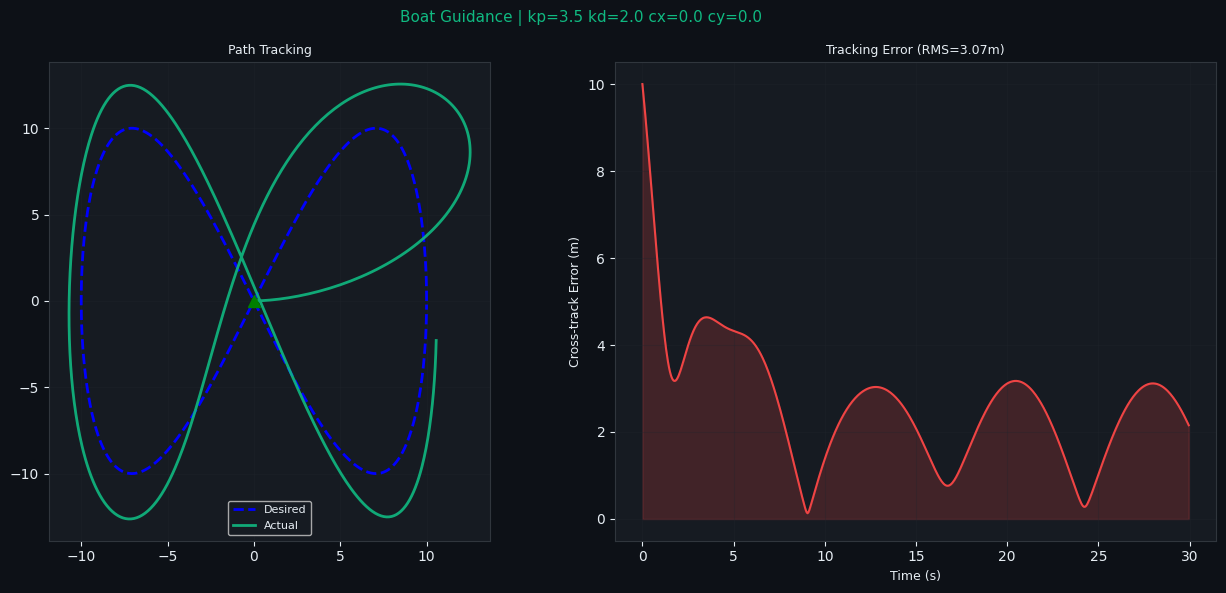

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2: Interactive Boat Tuning Widget
# ─────────────────────────────────────────────────────────────────────────────

def run_boat_interactive(kp, kd, cx, cy):
    boat = AutonomousBoat(kp=kp, kd=kd, current_x=cx, current_y=cy)
    t, x, y, xd, yd = boat.simulate()
    cross_track = np.sqrt((x-xd)**2 + (y-yd)**2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    fig.patch.set_facecolor('#0D1117')
    fig.suptitle(f'Boat Guidance | kp={kp} kd={kd} cx={cx} cy={cy}',
                 color='#10B981', fontsize=11)

    axes[0].plot(xd, yd, 'b--', linewidth=2, label='Desired')
    axes[0].plot(x, y, color='#10B981', linewidth=2, alpha=0.9, label='Actual')
    axes[0].plot(x[0], y[0], 'g^', markersize=9, zorder=5)
    axes[0].set_title('Path Tracking', color='#E6EDF3', fontsize=9)
    axes[0].set_aspect('equal')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, cross_track, color='#EF4444', linewidth=1.5)
    axes[1].fill_between(t, cross_track, alpha=0.2, color='#EF4444')
    axes[1].set_ylabel('Cross-track Error (m)', fontsize=9)
    axes[1].set_xlabel('Time (s)', fontsize=9)
    axes[1].set_title(f'Tracking Error (RMS={np.sqrt(np.mean(cross_track**2)):.2f}m)',
                       color='#E6EDF3', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

w_kp = widgets.FloatSlider(value=3.5,min=0.5,max=10.0,step=0.5,description='kp:')
w_kd = widgets.FloatSlider(value=2.0,min=0.0,max=8.0, step=0.5,description='kd:')
w_cx = widgets.FloatSlider(value=0.0,min=-3.0,max=3.0,step=0.25,description='current_x:',
                            style={'description_width':'70px'})
w_cy = widgets.FloatSlider(value=0.0,min=-3.0,max=3.0,step=0.25,description='current_y:',
                            style={'description_width':'70px'})
btn2 = widgets.Button(description='▶ Run Boat Sim', button_style='success')
out2 = widgets.Output()

def on_boat(b):
    with out2:
        clear_output(wait=True)
        run_boat_interactive(w_kp.value, w_kd.value, w_cx.value, w_cy.value)

btn2.on_click(on_boat)
display(widgets.VBox([widgets.HBox([w_kp, w_kd]),
                       widgets.HBox([w_cx, w_cy]), btn2, out2]))


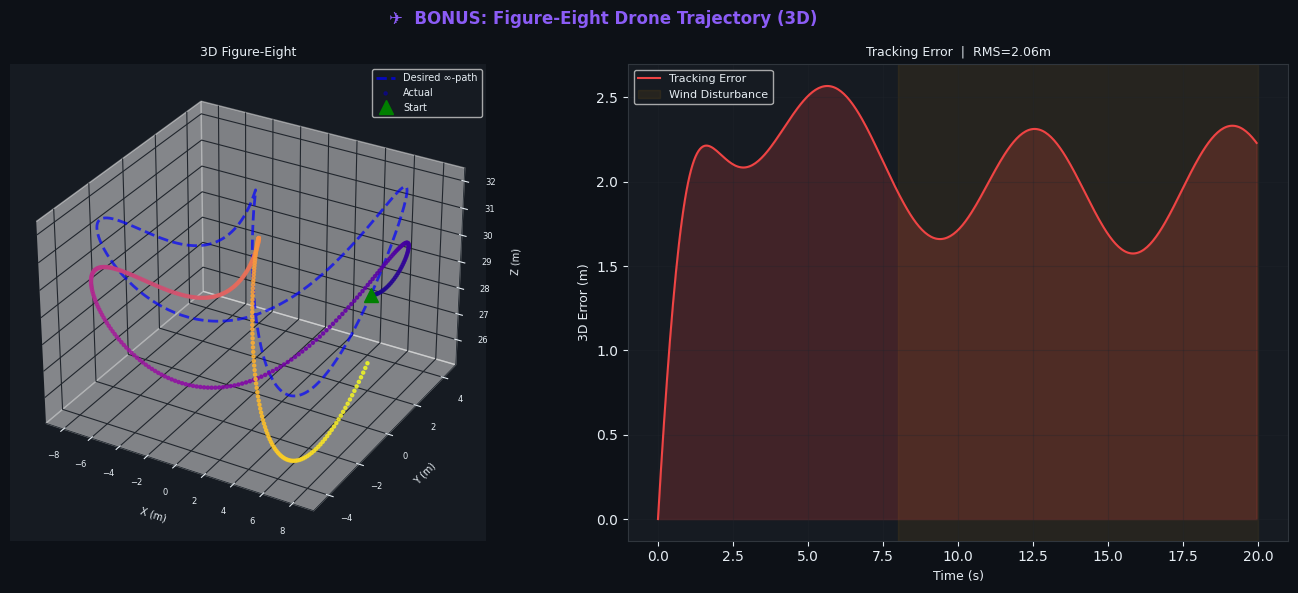

✅ Figure-eight simulation saved.  RMS Error: 2.064 m


In [16]:
import numpy as np
import matplotlib.pyplot as plt
# ─────────────────────────────────────────────────────────────────────────────
# BONUS: FIGURE-EIGHT DRONE TRAJECTORY SIMULATION
# ─────────────────────────────────────────────────────────────────────────────

class FigureEightDrone:
    """Drone following a 3D figure-eight (lemniscate) trajectory."""

    def __init__(self, kp=5.0, kd=3.0, ki=0.1,
                 wind_x=0.0, wind_y=0.0, wind_z=0.0,
                 dt=0.05, T=20.0, scale=8.0, altitude=30.0):
        self.kp = kp; self.kd = kd; self.ki = ki
        self.wind = np.array([wind_x, wind_y, wind_z])
        self.dt = dt; self.T = T
        self.scale = scale; self.alt = altitude

    def desired(self, t):
        s = 2*np.pi*t/self.T
        x = self.scale * np.cos(s)
        y = self.scale * np.sin(2*s) / 2
        z = self.alt + 2*np.sin(3*s)
        return np.array([x, y, z])

    def simulate(self):
        t_arr = np.arange(0, self.T, self.dt)
        n = len(t_arr)
        pos = np.zeros((n, 3)); vel = np.zeros((n, 3))
        pos[0] = self.desired(0)

        mass = 1.5; drag = 0.4
        integral = np.zeros(3); prev_err = np.zeros(3)

        for i in range(1, n):
            ti = t_arr[i]
            pd = self.desired(ti)
            err = pd - pos[i-1]
            integral += err * self.dt
            integral = np.clip(integral, -20, 20)
            deriv = (err - prev_err) / self.dt
            prev_err = err.copy()

            wind_f = self.wind if ti > self.T*0.4 else np.zeros(3)
            F = self.kp*err + self.ki*integral + self.kd*deriv + wind_f
            F[2] -= mass * 9.81  # gravity compensation

            acc = F / mass - drag * vel[i-1] / mass
            vel[i] = vel[i-1] + acc * self.dt
            pos[i] = pos[i-1] + vel[i] * self.dt
            pos[i, 2] = max(0, pos[i, 2])

        path = np.array([self.desired(t) for t in t_arr])
        return t_arr, pos, path

drone8 = FigureEightDrone(kp=6.0, kd=4.0, ki=0.15,
                           wind_x=0.5, wind_y=-0.3, wind_z=0.1,
                           T=20.0, scale=8.0, altitude=30.0)
t8, pos8, path8 = drone8.simulate()
err8 = np.linalg.norm(pos8 - path8, axis=1)

fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('✈️  BONUS: Figure-Eight Drone Trajectory (3D)',
             color='#8B5CF6', fontsize=12, fontweight='bold')

# 3D trajectory
ax3d = fig.add_subplot(121, projection='3d')
ax3d.set_facecolor('#161B22')
ax3d.plot(path8[:,0], path8[:,1], path8[:,2], 'b--', linewidth=2,
           alpha=0.7, label='Desired ∞-path')
sc3 = ax3d.scatter(pos8[:,0], pos8[:,1], pos8[:,2], c=t8,
                    cmap='plasma', s=5, alpha=0.8, label='Actual')
ax3d.plot(*pos8[0], 'g^', markersize=10, zorder=5, label='Start')
ax3d.set_xlabel('X (m)', fontsize=7, color='#E6EDF3')
ax3d.set_ylabel('Y (m)', fontsize=7, color='#E6EDF3')
ax3d.set_zlabel('Z (m)', fontsize=7, color='#E6EDF3')
ax3d.set_title('3D Figure-Eight', color='#E6EDF3', fontsize=9)
ax3d.legend(fontsize=7)
ax3d.tick_params(labelsize=6)

# Error over time
ax_err = fig.add_subplot(122)
ax_err.plot(t8, err8, color='#EF4444', linewidth=1.5, label='Tracking Error')
ax_err.fill_between(t8, err8, alpha=0.2, color='#EF4444')
ax_err.axvspan(drone8.T*0.4, drone8.T, alpha=0.07, color='orange',
                label='Wind Disturbance')
ax_err.set_xlabel('Time (s)', fontsize=9)
ax_err.set_ylabel('3D Error (m)', fontsize=9)
ax_err.set_title(f'Tracking Error  |  RMS={np.sqrt(np.mean(err8**2)):.2f}m',
                  color='#E6EDF3', fontsize=9)
ax_err.legend(fontsize=8); ax_err.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_eight_drone.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print(f"✅ Figure-eight simulation saved.  RMS Error: {np.sqrt(np.mean(err8**2)):.3f} m")

---
## 📋 Final Summary & Submission Checklist

| # | Project | Deliverable | Status |
|---|---------|-------------|--------|
| 1 | CanSat GCS | `cansat_gcs_dashboard.png` | ✅ |
| 1 | CanSat GCS | `cansat_error_codes.png` | ✅ |
| 1 | CanSat GCS | `cansat_telemetry_log.csv` | ✅ |
| 2 | Heat Wave | `heatwave_analysis.png` | ✅ |
| 2 | Heat Wave | `heatwave_vulnerability.png` | ✅ |
| 3 | Rocketry | `fem_mesh_study.png` | ✅ |
| 3 | Rocketry | `cfd_aerodynamics.png` | ✅ |
| 4 | Drone PID | `pid_tuning_comparison.png` | ✅ |
| 4 | Drone PID | `boat_guidance_plot.png` | ✅ |
| 4 | Bonus | `figure_eight_drone.png` | ✅ |

---
**Student Name:** Brijkishore Anilkumar Agarwal  
**Date of Submission:** 06/11/2026  

> *India Space Lab — Project Report 2026*  
> *All work completed as part of the 01 May – 15 June 2026 internship program.*


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE ALL OUTPUTS (List generated files)
# ─────────────────────────────────────────────────────────────────────────────
import os

output_files = [
    'cansat_gcs_dashboard.png',
    'cansat_error_codes.png',
    'cansat_telemetry_log.csv',
    'heatwave_analysis.png',
    'heatwave_vulnerability.png',
    'fem_mesh_study.png',
    'cfd_aerodynamics.png',
    'pid_tuning_comparison.png',
    'boat_guidance_plot.png',
    'figure_eight_drone.png',
]

print("\n📁 GENERATED OUTPUT FILES:")
print("="*50)
for f in output_files:
    exists = "✅" if os.path.exists(f) else "❌ (run cell above)"
    size   = f"{os.path.getsize(f)//1024} KB" if os.path.exists(f) else "-"
    print(f"  {exists}  {f:<35} {size}")
print("="*50)
print("\n🎉 All projects complete! Download files from Files panel (left sidebar).")



📁 GENERATED OUTPUT FILES:
  ✅  cansat_gcs_dashboard.png            172 KB
  ✅  cansat_error_codes.png              45 KB
  ✅  cansat_telemetry_log.csv            7 KB
  ✅  heatwave_analysis.png               319 KB
  ✅  heatwave_vulnerability.png          152 KB
  ✅  fem_mesh_study.png                  71 KB
  ✅  cfd_aerodynamics.png                160 KB
  ✅  pid_tuning_comparison.png           112 KB
  ✅  boat_guidance_plot.png              218 KB
  ✅  figure_eight_drone.png              221 KB

🎉 All projects complete! Download files from Files panel (left sidebar).
